This notebook allows for testing our L-VQE algorithm for solving the Max-Cut problem on $3$-regular graph instances.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from simulator import QuimbSimulator
from src.maxcut import MaxCut
from src.optimizer import COBYLA, SMO
from src.lvqe import LayerVQE

In [2]:
SEED=562    # for reproducibility
np.random.seed(SEED)

N_NODES = 42

N_LAYERS=2
K_PER_LAYER=30
K_FINAL=100

SIMULATOR=SMO          # COBYLA or SMO

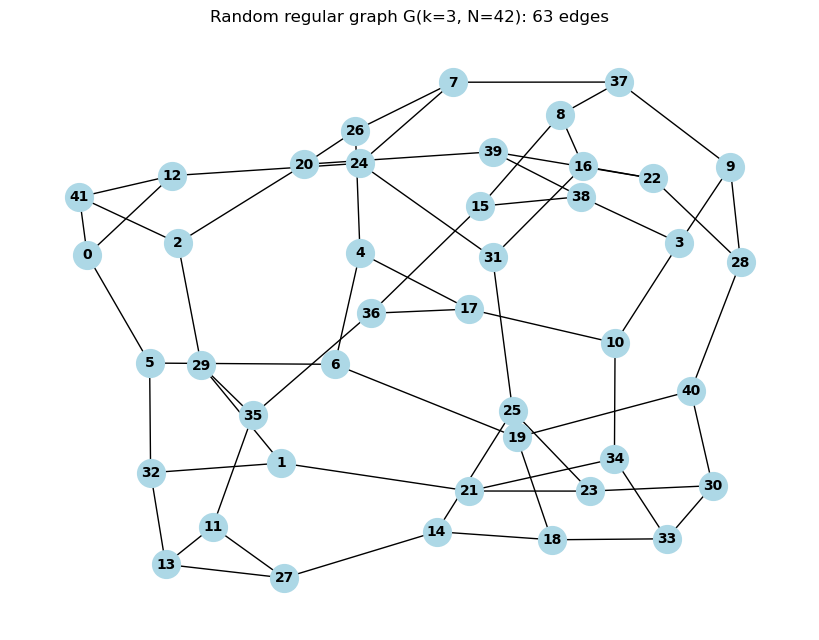

In [3]:
def get_random_graph(N: int, seed: int) -> nx.Graph:
    assert N % 2 == 0
    rng_graph = np.random.RandomState(seed)
    while True:
        G = nx.random_regular_graph(3, N, seed=rng_graph)
        if nx.is_connected(G):
            return G

G = get_random_graph(N_NODES, seed=SEED)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=SEED)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
    node_size=400, font_size=10, font_weight='bold')
plt.title(f"Random regular graph G(k=3, N={G.number_of_nodes()}): {G.number_of_edges()} edges")
plt.show()

In [4]:
problem = MaxCut(G, seed=SEED)
print(f"\nn_qubits: {problem.num_qubits}")
print(f"n_terms: {len(problem.hamiltonian_terms)}\n")

best_known = problem.best_known_value
print(f"best known cut value : {best_known}")
print(f"corresponding energy: {problem.cut_to_energy(best_known)}")



n_qubits: 41
n_terms: 63

best known cut value : 58.0
corresponding energy: 26.5


In [5]:
sim = QuimbSimulator()
lvqe = LayerVQE(
    problem=problem,
    simulator=sim,
    optimizer_class=SIMULATOR,
    n_layers=N_LAYERS,
    k_per_layer=K_PER_LAYER,
    k_final=K_FINAL,
    use_sampling=False,
    n_samples=1000,
    record_loss=True
)

result = lvqe.run()

print(f"\nFinal approximation ratio: {result['final_approx_ratio']:.4f}")

Starting L-VQE: 2 layers, 30 iter/layer, 100 final iter
Mode: exact expectation

Layer 0: 

Optimizer: SMO | max_iter=30


SMO: 100%|██████████| 30/30 [00:02<00:00, 10.46it/s, best_E=+14.5054]


layer 0: energy=+14.5054, approx_ratio=+0.7932

Layer 1 — 30 iterations (before convergence)
Optimizer: SMO | max_iter=30


SMO: 100%|██████████| 30/30 [00:03<00:00,  7.52it/s, best_E=+14.5054]


layer 1: energy=+14.5054, approx_ratio=+0.7932

Final layer — 100 iterations (final)
Optimizer: SMO | max_iter=100


SMO: 100%|██████████| 100/100 [00:18<00:00,  5.47it/s, best_E=+18.5000]

layer 2: energy=+18.5000, approx_ratio=+0.8621

Final approximation ratio: 0.8621


Saved → ../presentation/figures/ratio_vs_layers.pdf


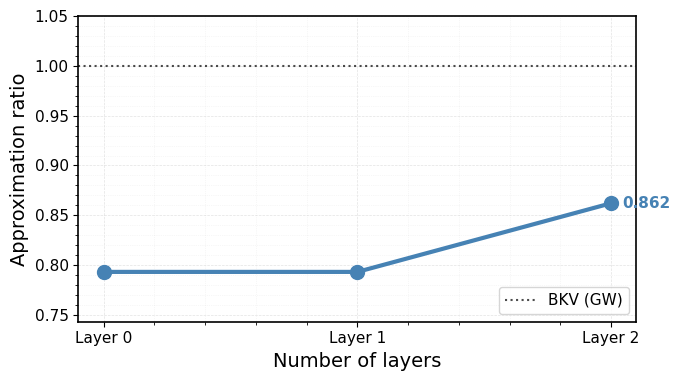

In [11]:

import matplotlib as mpl
import os

OUT_DIR = os.path.join('..', 'presentation', 'figures')
os.makedirs(OUT_DIR, exist_ok=True)

# plot 1: approx ratio vs. layers
layers = result['history']['layer']
ratios = [result['history']['approx_ratio'][l] for l in layers]

bkv_label = 'BKV (GW)' if N_NODES > 20 else 'BKV (brute-force)'

with mpl.rc_context({'font.size': 13, 'font.family': 'sans-serif', 'axes.linewidth': 1.2}):
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(layers, ratios, 'o-', color='steelblue', linewidth=3, markersize=10, zorder=3)

    ax.annotate(
        f"{ratios[-1]:.3f}",
        xy=(layers[-1], ratios[-1]),
        xytext=(8, 0), textcoords='offset points',
        fontsize=11, color='steelblue', va='center', fontweight='bold',
    )

    ax.axhline(y=1.0, color='black', linestyle=':', linewidth=1.5, alpha=0.7, label=bkv_label)

    ax.set_xlabel('Number of layers', fontsize=14)
    ax.set_ylabel('Approximation ratio', fontsize=14)
    ax.set_xticks(layers)
    ax.set_xticklabels([f'Layer {l}' for l in layers], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_ylim(bottom=max(0.0, min(ratios) - 0.05), top=1.05)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.grid(True, which='minor', linestyle=':', alpha=0.2)
    ax.minorticks_on()
    fig.tight_layout()

    out_path = os.path.join(OUT_DIR, 'ratio_vs_layers.pdf')
    fig.savefig(out_path, bbox_inches='tight')
    print(f"Saved → {out_path}")
    plt.show()


Saved → ../presentation/figures/loss_evolution.pdf


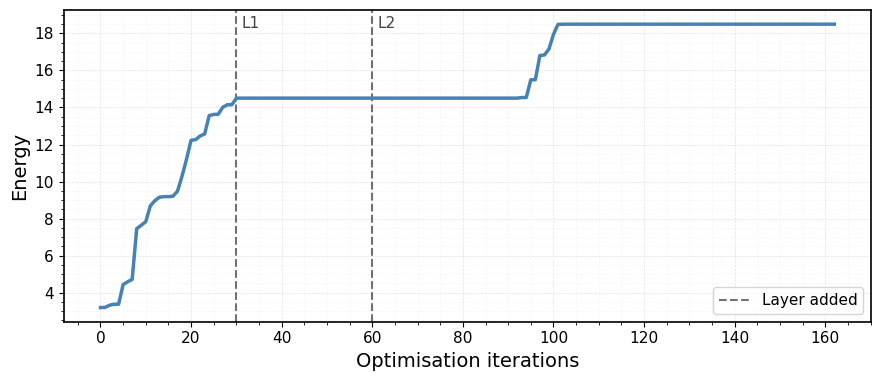

In [13]:

# plot 2: loss evolution across training
# Max-Cut is a maximization problem, so energy (loss) increases toward the optimum.
# New-layer parameters are zero-initialized → no abrupt jump at layer boundaries.

optimizer_loss = result['history']['optimizer_loss']
continuous_loss = np.concatenate(optimizer_loss)

with mpl.rc_context({'font.size': 13, 'font.family': 'sans-serif', 'axes.linewidth': 1.2}):
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(continuous_loss, color='steelblue', linewidth=2.5, zorder=3)

    y_min, y_max = ax.get_ylim()
    y_span = y_max - y_min

    for idx in range(1, N_LAYERS + 1):
        x = K_PER_LAYER * idx
        ax.axvline(x=x, color='black', linestyle='--', linewidth=1.5, alpha=0.55,
                   label='Layer added' if idx == 1 else '')
        ax.text(x + len(continuous_loss) * 0.007, y_max - 0.02 * y_span,
                f'L{idx}', fontsize=11, ha='left', va='top', color='black', alpha=0.75)

    ax.set_xlabel('Optimisation iterations', fontsize=14)
    ax.set_ylabel('Energy', fontsize=14)
    ax.tick_params(axis='both', labelsize=11)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.grid(True, which='minor', linestyle=':', alpha=0.2)
    ax.minorticks_on()
    fig.tight_layout()

    out_path = os.path.join(OUT_DIR, 'loss_evolution.pdf')
    fig.savefig(out_path, bbox_inches='tight')
    print(f"Saved → {out_path}")
    plt.show()

In [8]:
bitstrings = sim.get_most_frequent_assignments(result['final_params'], result['final_ansatz'], problem=problem)

print(f"  Most frequent assignments (best known cut: {problem.best_known_value:.0f})")
for i, (assignment, proba) in enumerate(bitstrings, start=1):
    cut_value = problem.evaluate(assignment)
    approx_ratio = cut_value / problem.best_known_value
    marker = " ✓" if cut_value == problem.best_known_value else ""
    print(f"  #{i}  prob={proba:5.1f}%  cut={cut_value:.0f}  "
          f"energy={problem.cut_to_energy(cut_value):.1f}  ratio={approx_ratio:.4f}{marker}")

  Most frequent assignments (best known cut: 58)
  #1  prob=100.0%  cut=50  energy=18.5  ratio=0.8621
